# Project

## Introduction to the Project
The S&P 500 (Standard & Poor's 500) is a stock market index that tracks the performance of 500 of the largest publicly traded companies in the United States. It is widely regarded as one of the best representations of the U.S. stock market and economy. Over the long term, the S&P 500 has shown consistent growth, making it a key focus for long-term investors. However, it can also experience significant volatility in the short term.

In this project, we will make our first attempt to build a momentum-based strategy to trade the S&P 500 index. At the end of the project, you will have built a program that you can later expand and customise to suit your needs. We will use the python packages numpy, scipy and sqlite3, among others, in this project.

Tips: Review the code snippets that we went through during the course. Reorganize them and you are half-way done! Try experimenting with different configurations of the confidence interval, the lookback window and the forecast horizon. Be brave and experiment with different ways of deciding the position size. You may be surprised by your talent!

Re-organize your code from the exercises into a Python program that 
1. read prices from a database
2. calibrate a GBM model on each day when new prices are received.
3. forecast the price in e.g. 10 days and
   1. calculate the confidence interval of the forecast
   2. calculate the expected shortfall from the price forecast
4. code your trading signals using the price forecast and the expected shortfall.
5. store your postions into the *positions* table after each trade.
6. produce a 1-year backtest record from 2020-06-01 to 2021-05-31.

**Hint**

1. Collect all the code related to the GBM model into a class

In [1]:
import csv
import sqlite3
from contextlib import closing
from datetime import datetime

import numpy as np
from scipy.stats import norm

conn = sqlite3.connect("SP500.db")
cs = conn.cursor()


In [2]:
class GBM:
    def __init__(self):
        self.mu, self.sigma = [np.nan] * 2
        self.rng = np.random.default_rng(12345)

    def simulate(self, N, K, Dt, S0):
        traj = np.full((N+1, K), np.nan)
        drift = (self.mu - self.sigma**2/2) * np.linspace(1, N, N) * Dt
        for k in range(K):
            W = np.cumsum(self.rng.standard_normal(N) * np.sqrt(Dt))
            traj[1:, k] = S0 * np.exp(drift + self.sigma * W)
            traj[0, k] = S0
        return traj

    def calibrate(self, trajectory, Dt):
        # estimate the first two moments of the log-increments with bootstrap
        increments = np.diff(np.log(trajectory))
        moments = np.zeros(2)
        for _ in range(10):
            x = self.rng.choice(increments, size=len(increments)//2, replace=True)
            moments[0] += np.mean(x) / 10
            moments[1] += np.mean(x**2) / 10
        std = np.sqrt(moments[1] - moments[0]**2)
        self.sigma = std / np.sqrt(Dt)
        self.mu = moments[0] / Dt + self.sigma**2 / 2

    def forecast(self, latest, T, confidence):
        expected = latest * np.exp(self.mu * T)
        mean = (self.mu - self.sigma**2/2) * T
        std = self.sigma * np.sqrt(T)
        quantiles = norm.ppf([(1 - confidence)/2, (1 + confidence)/2], loc=mean, scale=std)
        return {
            'confidence': confidence,
            'expected': expected,
            'interval': latest * np.exp(quantiles)
        }

    def expected_shortfall(self, T, confidence):
        mean = (self.mu - self.sigma**2/2) * T
        std = self.sigma * np.sqrt(T)
        return -mean + std * norm.pdf(norm.ppf(confidence)) / (1 - confidence)


In [3]:
# test your code here
model = GBM()
model.mu = 0.3
model.sigma = 0.2
simulated = model.simulate(500, 1, 1/250, 100)
simulated = simulated[:, 0]

model2 = GBM()
model2.calibrate(simulated, 1/250)

print(F"Calibrated: mu = {model2.mu}, sigma = {model2.sigma}")



Calibrated: mu = 0.16104341650828644, sigma = 0.20115341175178478


2. Write a function that prepares the database for trading, i.e.
   1. load the historical prices into the *prices* table
   2. create the *positions* table
   3. initialize the *positions* table with the your initial cash reserve. The initial *time_of_trade* can be any date before the earliest possible trading date.

    Call this function *prepare*.

In [4]:
def prepare():
    cs.execute("""
        create table if not exists prices (
            theday text not null,
            price real not null,
            primary key (theday)
        );
    """)
    cs.execute("delete from prices;")
    with closing(open("SP500.csv")) as f:
        reader = csv.DictReader(f, fieldnames=['date', 'price'], delimiter='\t')
        for row in reader:
            cs.execute("insert into prices values (?, ?);", (row['date'], float(row['price'])))
    cs.execute("""
        create table if not exists positions (
            time_of_trade text not null,
            instrument text not null,
            quantity real not null,
            cash real not null,
            primary key (time_of_trade, instrument)
        );
    """)
    cs.execute("delete from positions;")
    cs.execute("insert into positions values ('1666-01-01', 'SP500', 0, 1000000);")
    conn.commit()


In [5]:
# check whether you have loaded the prices correctly
prepare()
latest_prices = cs.execute("select * from prices order by theday desc limit 10")
for item in latest_prices:
    print(item)

('2021-05-28', 4204.11)
('2021-05-27', 4200.88)
('2021-05-26', 4195.99)
('2021-05-25', 4188.13)
('2021-05-24', 4197.05)
('2021-05-21', 4155.86)
('2021-05-20', 4159.12)
('2021-05-19', 4115.68)
('2021-05-18', 4127.83)
('2021-05-17', 4163.29)


3. Write a function that determines the trade size, i.e. how many units of the instrument you would like to own when the date is *which_day* and the price forecast of the instrument is *forecast* and the expected shortfall from the same forecast is *ES*.

In [6]:
def position_size(which_day, forecast, ES):
    cs.execute(F"""
        select quantity, cash from positions
        where time_of_trade < '{which_day}'
        order by time_of_trade desc
        limit 1;
    """)
    qty, cash = cs.fetchall()[0]
    cs.execute(F"""
        select price from prices
        where theday <= '{which_day}'
        order by theday desc
        limit 1;
    """)
    price = cs.fetchall()[0][0]
    wealth = qty * price + cash
    # risk at most 5% of the wealth in a tail event
    exposure = min(1.0, 0.05 / ES) if ES > 0 else 1.0
    lower, upper = forecast['interval']
    if price < lower:
        return wealth / price * exposure
    elif price > upper:
        return -wealth / price * exposure
    return qty


4. Write a function that, for a given date, calibrates a GBM model to the data prior to that date and that forecasts the price in 10 days. Call this function *analyse*.

In [7]:
def analyse(which_day):
    cs.execute(F"""
        select price from prices
        where theday <= '{which_day}'
        order by theday desc
        limit 120;
    """)
    prices = np.flipud(np.asarray(cs.fetchall()).flatten())
    model = GBM()
    Dt = 1/250
    model.calibrate(prices, Dt)
    forecast = model.forecast(prices[-1], 10*Dt, 0.10)
    ES = model.expected_shortfall(10*Dt, 0.95)
    return position_size(which_day, forecast, ES)


In [8]:
# Test the analyse function
test_dates = ['2021-05-09', '2021-05-14']
positions = [np.nan, np.nan]
for i in range(2):
    positions[i] = analyse(test_dates[i])
    print(F"{positions[i]} shares advised on {test_dates[i]}.")

236.26139961253128 shares advised on 2021-05-09.
239.5869520945889 shares advised on 2021-05-14.


5. The main loop of the program: Loop over the dates in the backtest period and use the *analyse* function to decide what to do on each day. Call this function *main*.

In [9]:
def main(begin_on):
    cs.execute(F"select theday from prices where theday >= '{begin_on}';")
    days = [d[0] for d in cs.fetchall()]
    asset = {
        'old': np.nan,
        'new': np.nan
    };
    cash = {
        'old': np.nan,
        'new': np.nan
    };
    cs.execute("delete from positions where time_of_trade > '2020-01-01';");
    for d in days:
        asset['new'] = analyse(d)
        cs.execute(F"""
        select quantity, cash from positions
        where time_of_trade < '{d}'
        order by time_of_trade desc
        limit 1;
        """);
        asset['old'], cash['old'] = cs.fetchall()[0];
        cs.execute(F"""
        select price from prices
        where theday <= '{d}'
        order by theday desc
        limit 1;
        """);
        latest = cs.fetchall()[0][0]
        trade_size = round(asset['new']) - round(asset['old']);
        if trade_size != 0:
            cash['new'] = cash['old'] - trade_size * latest;
            cs.execute(F"""
            insert into positions values
            ('{d}', 'SP500', {round(asset['new'])}, {cash['new']});
            """);
        conn.commit();



6. Connect to the database and create a *cursor* object associated with the connection. Share the connection and the cursor object across the program so that you don't have to connect to and disconnect from the database in every function of the program.

In [10]:
if __name__ == "__main__":
    with closing(sqlite3.connect("SP500.db")) as conn:
        with closing(conn.cursor()) as cs:
            prepare()
            main('2020-06-01')
    


In [11]:
# plot your track record
conn = sqlite3.connect("SP500.db")
cs = conn.cursor()

day1 = '2020-06-01'
day1_dt = datetime.strptime(day1, '%Y-%m-%d')

cs.execute(f"""
    select theday, quantity * price + cash as wealth
    from positions as PO
    join prices as PR
    on PO.time_of_trade = (
        select time_of_trade from positions
        where time_of_trade <= PR.theday
        order by time_of_trade desc limit 1
    )
    where theday >= '{day1}';
""")

records = cs.fetchall()

def calculate_T(record, day1_dt):
    theday, wealth = record
    theday_dt = datetime.strptime(theday, '%Y-%m-%d')
    T = (theday_dt - day1_dt).days
    return (T, wealth)

records = [calculate_T(record, day1_dt) for record in records]
W = np.asarray(records)

In [12]:
import matplotlib.pyplot as plt

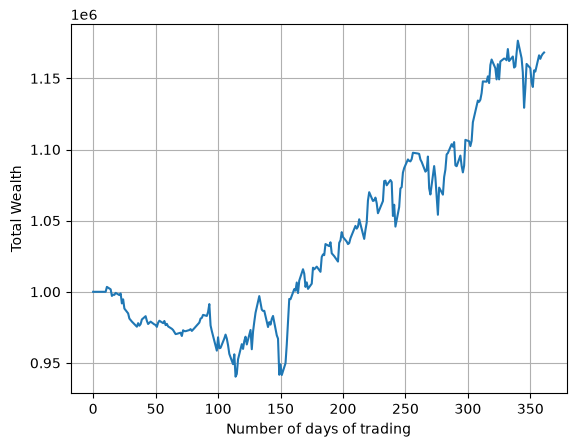

In [13]:
fig = plt.plot(W[:,0], W[:, 1])
plt.grid()
plt.xlabel("Number of days of trading")
plt.ylabel('Total Wealth');

7. Use the Student's t test to check the significance of the observed momentum in the lookback window on each day of the backtest period.

significant at 10%: 28 of 252 days
significant at 5%:  6 of 252 days


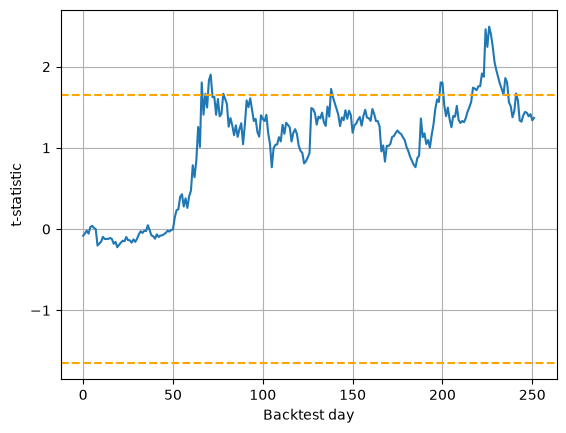

In [14]:
from scipy.stats import ttest_1samp

cs.execute("select theday from prices where theday >= '2020-06-01';")
backtest_days = [d[0] for d in cs.fetchall()]

t_stats, p_values = [], []
for d in backtest_days:
    cs.execute(F"""
        select price from prices
        where theday <= '{d}'
        order by theday desc
        limit 120;
    """)
    window = np.flipud(np.asarray(cs.fetchall()).flatten())
    increments = np.diff(np.log(window))
    t, p = ttest_1samp(increments, 0)
    t_stats.append(t)
    p_values.append(p)

print(F"significant at 10%: {np.sum(np.asarray(p_values) < 0.10)} of {len(backtest_days)} days")
print(F"significant at 5%:  {np.sum(np.asarray(p_values) < 0.05)} of {len(backtest_days)} days")

plt.plot(t_stats)
plt.axhline(1.645, color='orange', linestyle='--')
plt.axhline(-1.645, color='orange', linestyle='--')
plt.grid()
plt.xlabel("Backtest day")
plt.ylabel("t-statistic");


The momentum is significant at the 10% level on a small fraction of the days and rarely at 5%. I would act on it at the 10% level: waiting for 5% would keep the strategy flat almost all year, and the expected-shortfall sizing already limits the cost of a false signal.

8. Find the days on which the strategy performs the best and the worst.

In [15]:
cs.execute(F"""
    select theday, quantity * price + cash as wealth, price
    from positions as PO
    join prices as PR
    on PO.time_of_trade = (
        select time_of_trade from positions
        where time_of_trade <= PR.theday
        order by time_of_trade desc limit 1
    )
    where theday >= '{day1}';
""")
rows = cs.fetchall()
days = [r[0] for r in rows]
wealth = np.asarray([r[1] for r in rows])
spx = np.asarray([r[2] for r in rows])

daily_returns = np.diff(wealth) / wealth[:-1]
spx_returns = np.diff(spx) / spx[:-1]

best, worst = np.argmax(daily_returns), np.argmin(daily_returns)
print(F"best day:  {days[best+1]}  {daily_returns[best]:+.2%}  (S&P 500 {spx_returns[best]:+.2%})")
print(F"worst day: {days[worst+1]}  {daily_returns[worst]:+.2%}  (S&P 500 {spx_returns[worst]:+.2%})")


best day:  2021-03-01  +1.87%  (S&P 500 +2.38%)
worst day: 2020-10-28  -2.62%  (S&P 500 -3.53%)


On 2020-10-28 (worst day) the S&P 500 dropped about 3.5% on the second COVID wave and pre-election nerves, and the strategy was long. On 2021-03-01 (best day) the index rebounded about 2.4% as the late-February spike in bond yields eased.

9. Calculate the mean and the standard deviation of the daily returns, then the Sharpe ratio of the strategy in the test period.

In [16]:
mean_daily = np.mean(daily_returns)
std_daily = np.std(daily_returns)
sharpe = mean_daily / std_daily * np.sqrt(250)

print(F"mean daily return: {mean_daily:+.4%}")
print(F"std daily return:  {std_daily:.4%}")
print(F"total return:      {wealth[-1]/wealth[0]-1:+.2%}")
print(F"Sharpe ratio:      {sharpe:.2f}")


mean daily return: +0.0645%
std daily return:  0.7121%
total return:      +16.82%
Sharpe ratio:      1.43


The strategy returned about 17% in the test period with a Sharpe ratio of about 1.4 — far above a savings account, which paid roughly 0.5% per year in 2020-21, although not risk-free.